# 02 · Limpieza, EDA y Feature Engineering

**Proyecto ML — Predicción de precio de gafas graduadas (caso óptica).**

Inputs:
- `data/raw/lentiamo_graduadas.csv` — datos crudos del scraping (precio actual de mercado).
- `data/raw/marcas_tier.csv` — clasificación experta de las 75 marcas (Perplexity + NotebookLM).
- `data/raw/materiales_tier.csv` — clasificación experta de los materiales (Perplexity + NotebookLM)

Outputs:
- `data/processed/lentiamo_graduadas_clean.csv`
- `data/train/train.csv`, `data/test/test.csv`

## Plan
1. Carga + panorámica.
2. Limpieza: duplicados, NaN críticos + imputación de secundarios.
3. Reducción de multicolinealidad.
4. Enriquecimiento de marcas con clasificación experta.
5. Normalización categórica (color + material).
6. Tratamiento del target (log).
7. Feature engineering.
8. EDA del dataset enriquecido.
9. Train/test split.

## 0. Setup

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\juan_\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().parent
RAW   = ROOT / 'data' / 'raw'
PROC  = ROOT / 'data' / 'processed'
TRAIN = ROOT / 'data' / 'train'
TEST  = ROOT / 'data' / 'test'
for p in (PROC, TRAIN, TEST):
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y panorámica

In [3]:
df = pd.read_csv(RAW / 'lentiamo_graduadas_BACKUP_pre_patch.csv')
print(f'Forma original: {df.shape}')
df.head(3)

Forma original: (2875, 17)


,url,marca,modelo,tipo,genero,material_montura,forma,tipo_montura,color,talla,ancho_lente,ancho_puente,largo_varilla,calibre_total,peso,polarizadas,precio
0,https://www.lentiamo.es/ray-ban-0rx5698-8109-5...,Ray-Ban,0RX5698 8109 56,graduadas,Unisex,Acetato,Aviador,Montura completa,Marrón,M,56.0,14.0,145.0,133.0,190.0,NaN,112.9
1,https://www.lentiamo.es/saint-laurent-sl-574-0...,Saint Laurent,SL 574 001 52,graduadas,Unisex,Pasta,Rectangulares,Montura completa,Negro,M,52.0,21.0,145.0,139.0,155.0,NaN,249.9
2,https://www.lentiamo.es/saint-laurent-sl-m138-...,Saint Laurent,SL M138 001 55,graduadas,Mujer,Pasta,Cat Eye,Montura completa,Negro,M,55.0,18.0,145.0,138.0,160.0,NaN,249.9


In [4]:
info = pd.DataFrame({
    'dtype':  df.dtypes.astype(str),
    'NaN':    df.isna().sum(),
    'NaN_%':  (df.isna().mean() * 100).round(1),
    'únicos': df.nunique(),
})
info

,dtype,NaN,NaN_%,únicos
url,str,0,0.0,2875
marca,str,4,0.1,75
modelo,str,0,0.0,2875
tipo,str,0,0.0,1
genero,str,4,0.1,4
material_montura,str,4,0.1,12
forma,str,4,0.1,5
tipo_montura,str,4,0.1,3
color,str,8,0.3,15
talla,str,159,5.5,5


## 2. Limpieza inicial

- Drop columnas inútiles (`url`, `tipo`, `polarizadas` — siempre vacía en graduadas).
- Drop duplicados por `modelo`.
- Drop filas con `precio` o `marca` vacíos.

In [5]:
for col in ('url', 'tipo', 'polarizadas'):
    if col in df.columns:
        df = df.drop(columns=col)

antes = len(df)
df = df.drop_duplicates(subset=['modelo']).copy()
df = df.dropna(subset=['precio', 'marca']).copy()
print(f'Filas: {antes} → {len(df)} (drop dups + dropna críticos)')

Filas: 2875 → 2870 (drop dups + dropna críticos)


### 2b. Imputación de NaN secundarios

Las medidas tienen ~5 % de nulos. Imputamos por **mediana de la marca** (las marcas tienen tamaños típicos), fallback a mediana global. Categóricas → moda.

In [6]:
num_cols = ['ancho_lente', 'ancho_puente', 'largo_varilla', 'calibre_total', 'peso']
cat_cols = ['genero', 'material_montura', 'forma', 'tipo_montura', 'color', 'talla']

for c in num_cols:
    if c in df.columns:
        mediana_marca = df.groupby('marca')[c].transform('median')
        df[c] = df[c].fillna(mediana_marca).fillna(df[c].median())

for c in cat_cols:
    if c in df.columns:
        moda = df[c].mode()
        df[c] = df[c].fillna(moda.iloc[0] if len(moda) > 0 else 'Desconocido')

print('NaN tras imputación:')
print(df.isna().sum().sort_values(ascending=False).head(10))

NaN tras imputación:
marca               0
modelo              0
genero              0
material_montura    0
forma               0
tipo_montura        0
color               0
talla               0
ancho_lente         0
ancho_puente        0
dtype: int64


### 2c. Evidencia visual antes de reducir variables

Antes de eliminar `calibre_total`, comprobamos su relacion con el resto de medidas numericas. Si aparece muy correlacionada con `ancho_lente` y `ancho_puente`, tenemos una justificacion visual de que aporta informacion redundante.

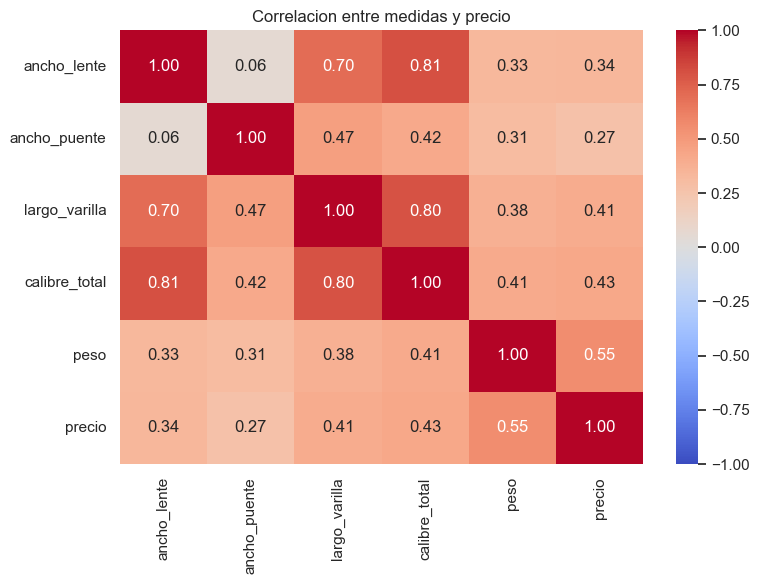

Correlaciones de calibre_total:
calibre_total    1.000000
ancho_lente      0.806224
largo_varilla    0.803988
precio           0.429367
ancho_puente     0.415230
peso             0.406368
Name: calibre_total, dtype: float64


In [7]:
num_cols_corr = ['ancho_lente', 'ancho_puente', 'largo_varilla', 'calibre_total', 'peso', 'precio']
corr_cols = [c for c in num_cols_corr if c in df.columns]
corr_medidas = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_medidas, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlacion entre medidas y precio')
plt.tight_layout()
plt.show()

if 'calibre_total' in corr_medidas.columns:
    print('Correlaciones de calibre_total:')
    print(corr_medidas['calibre_total'].sort_values(ascending=False))

## 3. Reducir multicolinealidad

$$\text{calibre\_total} \approx 2 \cdot \text{ancho\_lente} + \text{ancho\_puente}$$

→ tiramos `calibre_total`. `peso` se queda porque tiene info extra (densidad).

In [8]:
calibre_teo = 2 * df['ancho_lente'] + df['ancho_puente']
print(f'r(calibre_total, 2·ancho_lente + ancho_puente) = {df["calibre_total"].corr(calibre_teo):.3f}')
df = df.drop(columns=['calibre_total'])
print(f'Forma tras drop: {df.shape}')

r(calibre_total, 2·ancho_lente + ancho_puente) = 0.872
Forma tras drop: (2870, 13)


## 4. Enriquecimiento con clasificación experta de marcas

Merge con `marcas_tier.csv` → 5 features nuevas: `tier`, `segmento`, `pais_origen`, `precio_min`, `precio_max`.

El modelo sabrá que Tom Ford es lujo no por casualidad sino por enriquecimiento experto.

In [9]:
marcas_tier = pd.read_csv(RAW / 'marcas_tier.csv', sep=';')
print(f'Marcas clasificadas: {len(marcas_tier)}')
marcas_tier.head()

Marcas clasificadas: 75


,marca,tier,segmento,pais_origen,precio_min,precio_max,notas
0,Armani Exchange,gama_media,moda_premium,Italia,120,240,(estimación) Marca premium derivada de Armani ...
1,Arnette,gama_media,moda_casual,Estados Unidos,60,140,(estimación) Marca joven y casual precio medio...
2,Balenciaga,lujo,moda_lujo,Francia/España (marca matriz),230,500,Alta gama diseño de lujo precios altos [1]
3,Barbie,licencia_infantil,infantil_licencia,Estados Unidos,40,120,Clasificación infantil licencia precio medio-b...
4,Blackfin,gama_media,moda_premium,Italia,150,300,Marca italiana posicionamiento medio-alto [1]


In [10]:
marcas_dataset = set(df['marca'].dropna().str.strip())
marcas_csv     = set(marcas_tier['marca'].str.strip())
faltantes = marcas_dataset - marcas_csv
if faltantes:
    print(f'⚠ Marcas SIN match en CSV ({len(faltantes)}):')
    for m in sorted(faltantes):
        print(f'   · {m!r}')
else:
    print(f'✅ Las {len(marcas_dataset)} marcas del dataset están todas clasificadas.')

✅ Las 75 marcas del dataset están todas clasificadas.


In [11]:
df = df.merge(marcas_tier, on='marca', how='left')

# Imputación defensiva por si alguna marca no matcheó
df['tier']        = df['tier'].fillna('gama_media')
df['segmento']    = df['segmento'].fillna('moda_casual')
df['pais_origen'] = df['pais_origen'].fillna('Desconocido')
df['precio_min']  = df['precio_min'].fillna(0).astype(float)
df['precio_max']  = df['precio_max'].fillna(0).astype(float)

if 'notas' in df.columns:
    df = df.drop(columns=['notas'])

print('Distribución de tier:')
print(df['tier'].value_counts())
print(f'\nForma: {df.shape}')

Distribución de tier:
tier
gama_media           1601
lujo                  686
premium               461
licencia_infantil     122
Name: count, dtype: int64

Forma: (2870, 18)


## 5. Normalización categórica

### 5a. Color → 13 colores básicos

In [12]:
MAPEO_COLOR = {
    'negro':       ['negro', 'black'],
    'marron':      ['marrón', 'marron', 'havana', 'café', 'brown', 'caoba'],
    'gris':        ['gris', 'grafito', 'grey', 'antracita', 'plomo'],
    'transparente':['transparente', 'cristal', 'crystal', 'translúcido', 'translucido'],
    'azul':        ['azul', 'navy', 'blue'],
    'dorado':      ['dorado', 'oro', 'gold'],
    'plateado':    ['plateado', 'plata', 'silver'],
    'rojo':        ['rojo', 'red', 'burdeos', 'borgoña'],
    'rosa':        ['rosa', 'rosado', 'pink'],
    'verde':       ['verde', 'green', 'oliva'],
    'morado':      ['morado', 'violeta', 'purple', 'lila'],
    'blanco':      ['blanco', 'white', 'beige', 'crema', 'marfil'],
    'tortoise':    ['tortoise'],
}

def normalizar_color(s):
    if pd.isna(s):
        return 'otro'
    s_low = str(s).lower()
    for canon, sinonimos in MAPEO_COLOR.items():
        if any(syn in s_low for syn in sinonimos):
            return canon
    return 'otro'

df['color'] = df['color'].apply(normalizar_color)
df['color'].value_counts()

color
negro           873
marron          507
azul            430
gris            223
rosa            167
rojo            154
verde           122
dorado          121
morado          103
transparente     67
plateado         60
blanco           28
otro             15
Name: count, dtype: int64

### 5b. Material — agrupar variantes Eco-friendly

Las 5 variantes `Eco-friendly - X` (Econyl, Eco-poliamida, Bio-acetato, Bio-based, Eco Co-poliéster) son el mismo concepto: monturas sostenibles. Se agrupan en `Eco-friendly` (≈137 productos).

Conservamos `Propionato` (28 productos) como categoría propia — un árbol aprende perfectamente con esa muestra. **No aplicamos ningún umbral arbitrario tipo `<30 → Otros`**: las 8 categorías resultantes son todas válidas y aportan info distinta.

In [13]:
df['material_montura'].value_counts()

material_montura
Pasta                              1518
Metal                               500
Acetato                             326
Metal/Pasta                         250
Eco-friendly - Econyl                73
Titanio                              69
Nylon                                42
Eco-friendly - Eco-poliamida         31
Propionato                           28
Eco-friendly - Bio-acetato           25
Eco-friendly - Bio-based              7
Eco-friendly - Eco Co-poliéster       1
Name: count, dtype: int64

In [14]:
df['material_montura'] = df['material_montura'].apply(
    lambda x: 'Eco-friendly' if isinstance(x, str) and x.startswith('Eco-friendly') else x
)
df['material_montura'].value_counts()

material_montura
Pasta           1518
Metal            500
Acetato          326
Metal/Pasta      250
Eco-friendly     137
Titanio           69
Nylon             42
Propionato        28
Name: count, dtype: int64

### 5c. Enriquecimiento de materiales

`data/raw/materiales_tier.csv` (mismo flujo Perplexity + NotebookLM aplicado a materiales), se añaden `categoria_material`, `gama_material` y `peso_relativo` como features.

In [15]:
materiales_path = RAW / 'materiales_tier.csv'
if materiales_path.exists():
    materiales_tier = pd.read_csv(materiales_path, sep=',')
    materiales_tier = materiales_tier.rename(columns={
        'material':  'material_montura',
        'categoria': 'categoria_material',
        'gama':      'gama_material',
    })
    cols_merge = ['material_montura', 'categoria_material', 'gama_material', 'peso_relativo']
    df = df.merge(materiales_tier[cols_merge], on='material_montura', how='left')
    df['categoria_material'] = df['categoria_material'].fillna('otro')
    df['gama_material']      = df['gama_material'].fillna('gama_media')
    df['peso_relativo']      = df['peso_relativo'].fillna('medio')
    print('✅ materiales_tier.csv integrado.')
    print(df[['categoria_material', 'gama_material', 'peso_relativo']].apply(lambda s: s.value_counts()).fillna(0).astype(int))
else:
    print('ℹ materiales_tier.csv no encontrado → seguimos solo con material_montura.')
    print('  (Si lo generas con Perplexity + NotebookLM, vuelve a ejecutar el notebook.)')

✅ materiales_tier.csv integrado.
            categoria_material  gama_material  peso_relativo
acetato                   1844              0              0
alta                         0             69              0
gama_media                   0            137              0
ligero                       0              0           1983
media                        0           2164              0
media_alta                   0            500              0
medio                        0              0            887
metal                      500              0              0
mezcla                     250              0              0
otro                       137              0              0
poliamida                   42              0              0
propionato                  28              0              0
titanio                     69              0              0


## 6. Outliers en el target

Creación de `log_precio` como target alternativo (la regresión lineal suele funcionar mejor sobre log).

Rango de precio: 18.89 € — 479.90 €
Mediana:         113.90 €
p95 / p99:       280 € / 350 €

Asimetría precio:     1.08
Asimetría log_precio: 0.01

→ Usaremos `precio` para árboles y `log_precio` para lineales.
→ En el notebook 03, las métricas se calculan SIEMPRE en € (back-transform si se entrena en log).


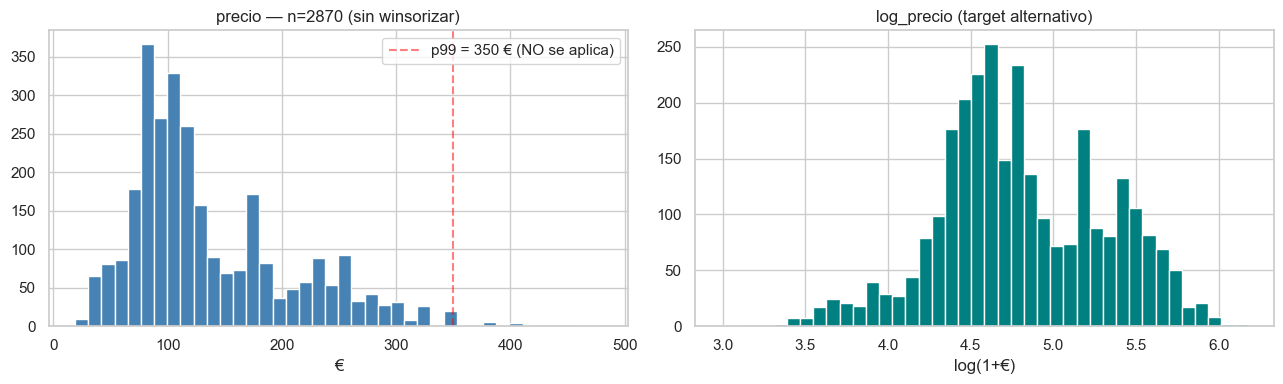

In [19]:
# DECISIÓN CONCEPTUAL: no winsorizar.
# Los precios altos (Tom Ford, Saint Laurent, Bottega Veneta) NO son outliers,
# son observaciones reales del segmento premium. Si los recortásemos, el modelo
# aprendería a infraestimar productos caros, que es donde la óptica gana margen.
#
# En su lugar: añadimos log_precio como target alternativo (transformación
# no destructiva, útil para modelos lineales).

df['log_precio'] = np.log1p(df['precio'])

print(f'Rango de precio: {df["precio"].min():.2f} € — {df["precio"].max():.2f} €')
print(f'Mediana:         {df["precio"].median():.2f} €')
print(f'p95 / p99:       {df["precio"].quantile(0.95):.0f} € / {df["precio"].quantile(0.99):.0f} €')
print()
print(f'Asimetría precio:     {df["precio"].skew():.2f}')
print(f'Asimetría log_precio: {df["log_precio"].skew():.2f}')
print()
print('→ Usaremos `precio` para árboles y `log_precio` para lineales.')
print('→ En el notebook 03, las métricas se calculan SIEMPRE en € (back-transform si se entrena en log).')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['precio'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'precio — n={len(df)} (sin winsorizar)')
axes[0].set_xlabel('€')
axes[0].axvline(df['precio'].quantile(0.99), color='red', linestyle='--', alpha=0.5,
                label=f'p99 = {df["precio"].quantile(0.99):.0f} € (NO se aplica)')
axes[0].legend()
axes[1].hist(df['log_precio'], bins=40, color='teal', edgecolor='white')
axes[1].set_title('log_precio (target alternativo)')
axes[1].set_xlabel('log(1+€)')
plt.tight_layout()
plt.show()

## 7. Feature engineering

In [20]:
# 7.1 — aspect_ratio
df['aspect_ratio'] = df['ancho_lente'] / df['largo_varilla']

# 7.2 — densidad: peso / área aproximada (proxy de material denso)
df['area_aprox'] = df['ancho_lente'] * df['ancho_puente']
df['densidad']   = df['peso'] / df['area_aprox']

# 7.3 — ancho_total reconstruido (info que perdimos al tirar calibre_total)
df['ancho_total'] = 2 * df['ancho_lente'] + df['ancho_puente']

# 7.4 — montura completa (binary)
df['montura_completa'] = (df['tipo_montura']
                           .str.contains('completa', case=False, na=False)
                           .astype(int))

# 7.5 — es_unisex
df['es_unisex'] = df['genero'].str.lower().eq('unisex').astype(int)

# 7.6 — color_basico (negro o marrón = lo más vendido en óptica)
df['color_basico'] = df['color'].isin(['negro', 'marron']).astype(int)

# 7.7 — material_eco (binary)
df['material_eco'] = (df['material_montura'] == 'Eco-friendly').astype(int)

# 7.8 — precio_medio_marca: ancla del precio típico esperado por la marca
df['precio_medio_marca'] = (df['precio_min'] + df['precio_max']) / 2
df['precio_medio_marca'] = df['precio_medio_marca'].replace(0, np.nan).fillna(df['precio'].median())

print(f'Forma tras feature engineering: {df.shape}')

Forma tras feature engineering: (2870, 31)


In [21]:
print('Columnas finales:')
for c in df.columns:
    print(f'  · {c:<22} {df[c].dtype}')

Columnas finales:
  · marca                  str
  · modelo                 str
  · genero                 str
  · material_montura       str
  · forma                  str
  · tipo_montura           str
  · color                  str
  · talla                  str
  · ancho_lente            float64
  · ancho_puente           float64
  · largo_varilla          float64
  · peso                   float64
  · precio                 float64
  · tier                   str
  · segmento               str
  · pais_origen            str
  · precio_min             float64
  · precio_max             float64
  · categoria_material     str
  · gama_material          str
  · peso_relativo          str
  · log_precio             float64
  · aspect_ratio           float64
  · area_aprox             float64
  · densidad               float64
  · ancho_total            float64
  · montura_completa       int64
  · es_unisex              int64
  · color_basico           int64
  · material_eco           in

## 8. EDA del dataset enriquecido

### 8a. Score unificado de asociación con precio (cat + num en la misma escala 0-1)

In [22]:
def correlation_ratio(categorias, valores):
    """η² — fracción de varianza de `valores` explicada por la categoría."""
    cats = pd.Categorical(categorias)
    valores = pd.Series(valores).reset_index(drop=True)
    codes = pd.Series(cats.codes).reset_index(drop=True)
    valid = valores.notna() & (codes >= 0)
    if valid.sum() < 2:
        return np.nan
    valores = valores[valid].values
    codes   = codes[valid].values
    overall = valores.mean()
    ss_total = ((valores - overall) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = sum(
        len(valores[codes == c]) * (valores[codes == c].mean() - overall) ** 2
        for c in np.unique(codes)
    )
    return ss_between / ss_total

feats_cat = ['marca', 'tier', 'segmento', 'pais_origen',
             'genero', 'material_montura', 'forma', 'tipo_montura',
             'color', 'talla']
if 'categoria_material' in df.columns:
    feats_cat += ['categoria_material', 'gama_material', 'peso_relativo']

feats_num = ['ancho_lente', 'ancho_puente', 'largo_varilla', 'peso',
             'aspect_ratio', 'densidad', 'ancho_total',
             'precio_min', 'precio_max', 'precio_medio_marca',
             'montura_completa', 'es_unisex', 'color_basico', 'material_eco']

scores = {}
for c in feats_num:
    sub = df[[c, 'precio']].dropna()
    r = sub[c].corr(sub['precio'])
    scores[c] = (r ** 2) if pd.notna(r) else np.nan
for c in feats_cat:
    sub = df[[c, 'precio']].dropna()
    scores[c] = correlation_ratio(sub[c], sub['precio'])

scores_df = pd.Series(scores, name='score').sort_values(ascending=False).round(3)
scores_df

marca                 0.815
precio_min            0.492
precio_medio_marca    0.483
precio_max            0.475
segmento              0.471
tier                  0.447
peso                  0.308
pais_origen           0.262
densidad              0.227
genero                0.181
talla                 0.168
largo_varilla         0.165
ancho_total           0.154
ancho_lente           0.116
material_montura      0.089
color                 0.085
categoria_material    0.076
ancho_puente          0.074
gama_material         0.067
color_basico          0.031
forma                 0.031
aspect_ratio          0.010
material_eco          0.008
tipo_montura          0.008
es_unisex             0.005
montura_completa      0.003
peso_relativo         0.001
Name: score, dtype: float64

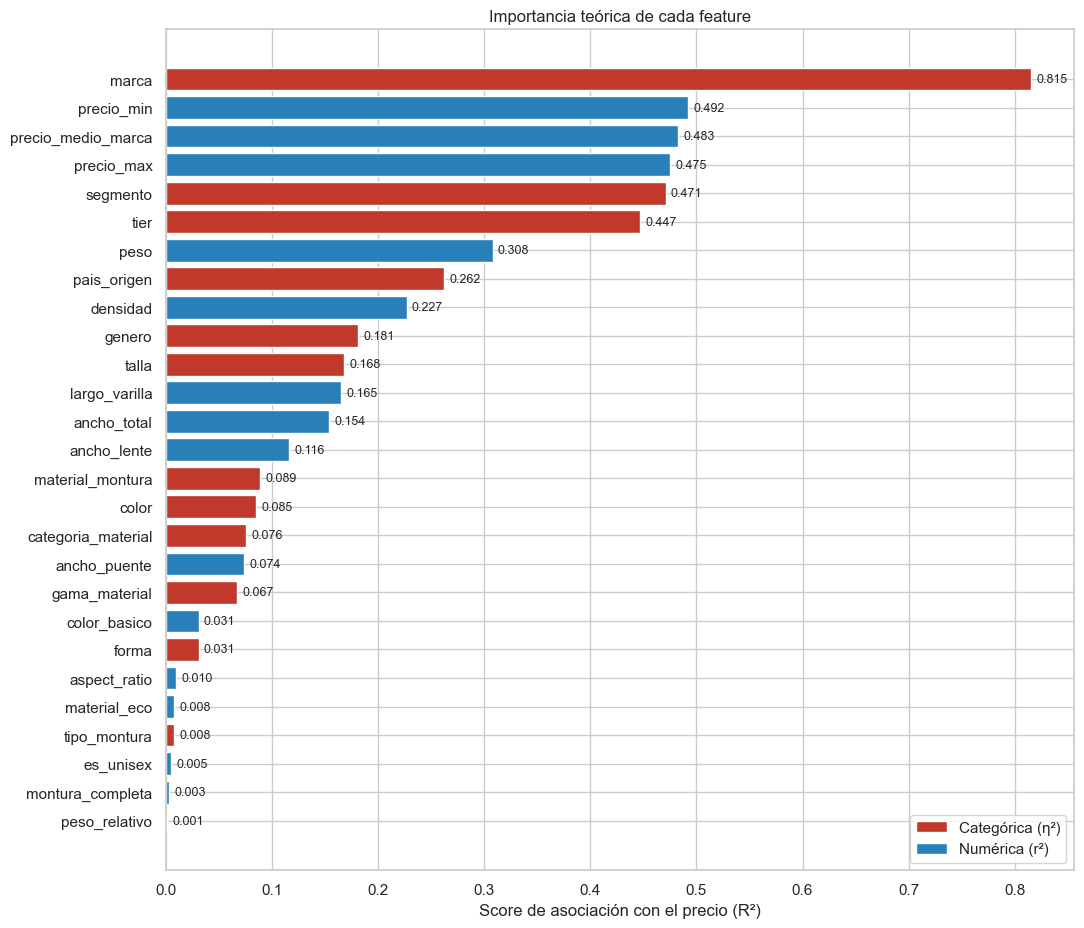

In [23]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(11, max(6, len(scores_df) * 0.35)))
colores = ['#c0392b' if v in feats_cat else '#2980b9' for v in scores_df.index]
ax.barh(scores_df.index[::-1], scores_df.values[::-1], color=colores[::-1])
ax.set_xlabel('Score de asociación con el precio (R²)')
ax.set_title('Importancia teórica de cada feature')
for i, v in enumerate(scores_df.values[::-1]):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.legend(handles=[
    Patch(facecolor='#c0392b', label='Categórica (η²)'),
    Patch(facecolor='#2980b9', label='Numérica (r²)'),
], loc='lower right')
plt.tight_layout()
plt.show()

In [24]:
rename_map = {'tier': 'gama_marca', 'segmento': 'segmento_comercial'}
df = df.rename(columns=rename_map)
feats_cat = [rename_map.get(c, c) for c in feats_cat]
scores_df = scores_df.rename(index=rename_map)

print('Columnas renombradas:')
print(rename_map)

Columnas renombradas:
{'tier': 'gama_marca', 'segmento': 'segmento_comercial'}


### 8b. Boxplot precio por `gama_marca` y `segmento_comercial`

C:\Users\juan_\AppData\Local\Temp\ipykernel_3456\1409498424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gama_marca', y='precio', order=orden_tier, ax=axes[0], palette='RdYlGn_r')
C:\Users\juan_\AppData\Local\Temp\ipykernel_3456\1409498424.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segmento_comercial', y='precio', ax=axes[1], palette='Set2')


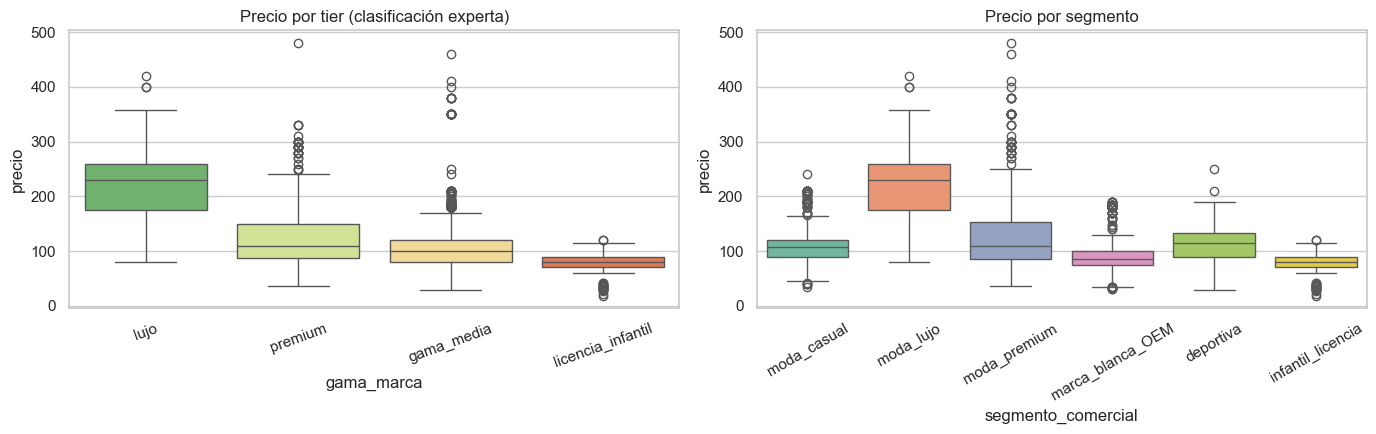

Resumen por gama_marca:


,count,mean,median,min,max
gama_marca,,,,,
lujo,686,221.0,229.9,79.6,419.9
premium,461,126.9,109.9,36.6,479.9
gama_media,1601,108.9,99.9,29.0,459.9
licencia_infantil,122,76.7,80.0,18.9,119.9


In [25]:
orden_tier = ['lujo', 'premium', 'gama_media', 'gama_baja', 'licencia_infantil']
orden_tier = [t for t in orden_tier if t in df['gama_marca'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x='gama_marca', y='precio', order=orden_tier, ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('Precio por tier (clasificación experta)')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='segmento_comercial', y='precio', ax=axes[1], palette='Set2')
axes[1].set_title('Precio por segmento')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

resumen_tier = (df.groupby('gama_marca')['precio']
                .agg(['count', 'mean', 'median', 'min', 'max'])
                .round(1)
                .sort_values('median', ascending=False))
print('Resumen por gama_marca:')
resumen_tier

### 8c. Correlación entre numéricas

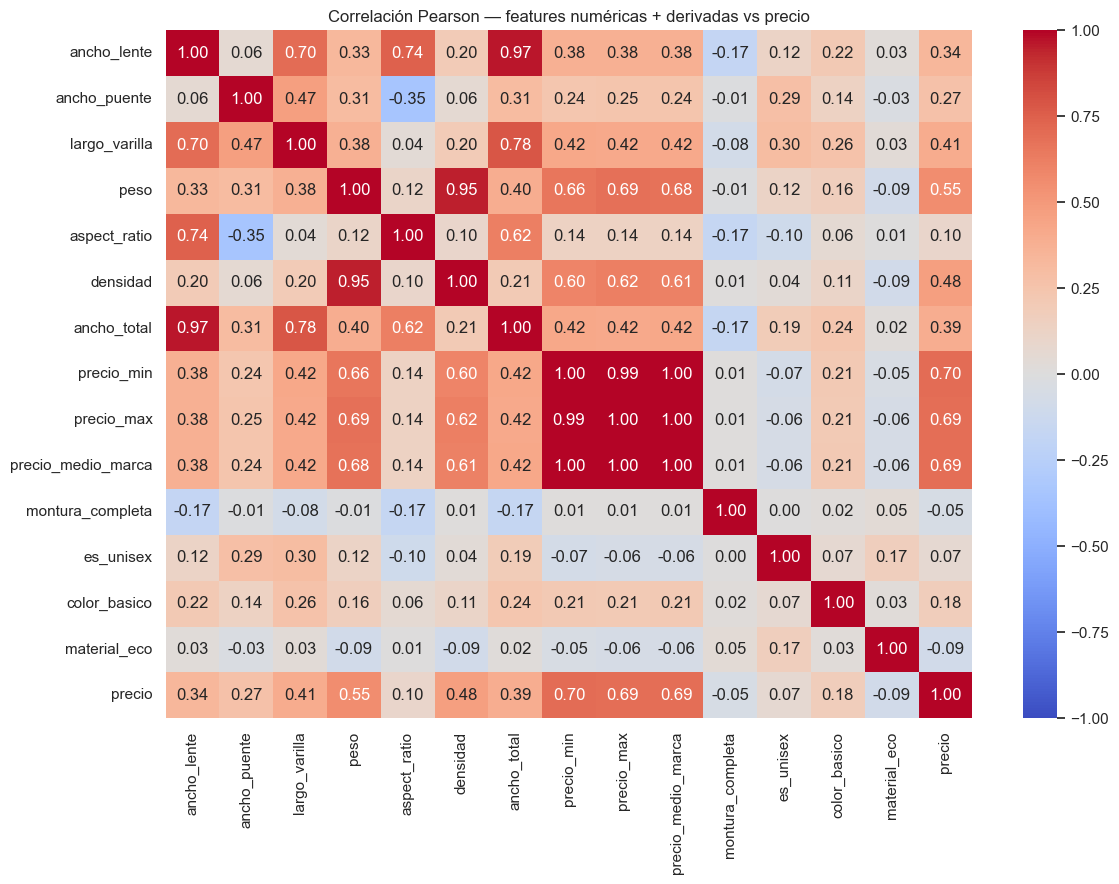

In [26]:
num_para_heatmap = feats_num + ['precio']
plt.figure(figsize=(12, 9))
corr = df[num_para_heatmap].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación Pearson — features numéricas + derivadas vs precio')
plt.tight_layout()
plt.show()

## 9. Train/test split y guardado

**No hago encoding aquí** — eso va dentro del Pipeline en el notebook 03 para evitar leakage.

In [27]:
# Reordenar columnas: identificadores → features → targets
ids   = [c for c in ['modelo'] if c in df.columns]
tgts  = ['precio', 'log_precio']
feats = [c for c in df.columns if c not in ids + tgts]
df = df[ids + feats + tgts]

df.to_csv(PROC / 'lentiamo_graduadas_clean.csv', index=False)
print(f'✅ {PROC / "lentiamo_graduadas_clean.csv"}  ({df.shape[0]} filas, {df.shape[1]} cols)')

train, test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
train.to_csv(TRAIN / 'train.csv', index=False)
test.to_csv(TEST / 'test.csv', index=False)
print(f'✅ train.csv: {len(train)} filas')
print(f'✅ test.csv:  {len(test)} filas')

✅ c:\Users\juan_\Desktop\THE-BRIDGE\RepositorioJuanAMM\Proyecto ML\data\processed\lentiamo_graduadas_clean.csv  (2870 filas, 31 cols)
✅ train.csv: 2296 filas
✅ test.csv:  574 filas


## 10. Resumen final

In [29]:
print('=== Resumen final ===')
print(f'Filas:                 {len(df)}')
print(f'Columnas:              {df.shape[1]}')
print(f'Features categóricas:  {len(feats_cat)}')
print(f'Features numéricas:    {len(feats_num)}')
print(f'Train / test:          {len(train)} / {len(test)}')
print()
print('Top 5 features por score teórico de asociación con precio:')
for k, v in scores_df.head().items():
    tipo = 'cat' if k in feats_cat else 'num'
    print(f'  · {k:<22} ({tipo}): {v:.3f}')
print()
print('Distribución de gama por marca:')
for t, n in df['gama_marca'].value_counts().items():
    print(f'  · {t:<22} {n:>4} ({n/len(df)*100:.1f}%)')

=== Resumen final ===
Filas:                 2870
Columnas:              31
Features categóricas:  13
Features numéricas:    14
Train / test:          2296 / 574

Top 5 features por score teórico de asociación con precio:
  · marca                  (cat): 0.815
  · precio_min             (num): 0.492
  · precio_medio_marca     (num): 0.483
  · precio_max             (num): 0.475
  · segmento_comercial     (cat): 0.471

Distribución de gama por marca:
  · gama_media             1601 (55.8%)
  · lujo                    686 (23.9%)
  · premium                 461 (16.1%)
  · licencia_infantil       122 (4.3%)
